<a href="https://colab.research.google.com/github/lorramrj/AI-Fundamentals/blob/main/001-Analysis_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Análise e Avaliação de Modelos de Machine Learning

Ao analisar um modelo, seguimos uma estrutura lógica para garantir uma avaliação completa e identificar possíveis problemas:

1.  **Definição do Problema e Dados:**
    *   Qual é o objetivo do modelo? (Classificação, Regressão, Clusterização?)
    *   Os dados são relevantes, limpos e representativos?
    *   Quais são as *features* (variáveis de entrada) e o *target* (variável de saída)?

2.  **Divisão dos Dados:**
    *   Como os dados foram divididos em conjunto de Treino, Validação e Teste?
    *   A divisão é aleatória e estratificada (se aplicável, para manter a proporção das classes)?

3.  **Seleção e Treinamento do Modelo:**
    *   Qual algoritmo foi escolhido e por quê?
    *   Como os parâmetros (aprendidos durante o treino) e hiperparâmetros (configurados antes do treino) foram definidos?
    *   O modelo conseguiu **minimizar a função de perda (loss function)** durante o treinamento?

4.  **Avaliação de Desempenho (Métricas):**
    *   Quais métricas foram usadas para avaliar o modelo no conjunto de **validação** e **teste**?
    *   Para Regressão: MSE, RMSE, MAE, R²?
    *   Para Classificação: Acurácia, Precisão, Recall, F1-Score, Curva ROC, AUC, Matriz de Confusão?

5.  **Análise de Diagnóstico (Overfitting/Underfitting):**
    *   **Comparar desempenho:** O desempenho no treino e validação/teste são próximos?
        *   **Treino bom, Teste ruim = Overfitting.** O modelo decorou os dados de treino.
        *   **Treino ruim, Teste ruim = Underfitting.** O modelo é muito simples para os dados.
    *   **Curvas de Aprendizado:** Gráficos da função de perda (ou métrica) versus número de iterações/épocas para treino e validação.

6.  **Interpretabilidade e Explicabilidade (Opcional, mas Importante):**
    *   Por que o modelo fez uma determinada previsão?
    *   Quais features são mais importantes para as previsões do modelo?

7.  **Iteração e Otimização:**
    *   Com base na análise, o que pode ser ajustado?
    *   Engenharia de features, ajuste de hiperparâmetros, mudança de algoritmo, coleta de mais dados?

---

In [66]:
# Instalar scikit-learn para gerar dados sintéticos e modelos
# !pip install scikit-learn matplotlib seaborn numpy --quiet

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### Exemplo Gráfico: Overfitting (Sobreajuste) e Underfitting (Subajuste)

Vamos gerar um conjunto de dados sintético que segue uma tendência quadrática com algum ruído. Em seguida, treinaremos modelos de regressão polinomial de diferentes graus para ilustrar o underfitting, o bom ajuste e o overfitting.

*   **Underfitting:** O modelo é muito simples (grau 1, uma linha reta) para capturar a curvatura dos dados.
*   **Bom Ajuste:** O modelo tem a complexidade adequada (grau 2) para os dados.
*   **Overfitting:** O modelo é muito complexo (grau alto, como 15), tenta capturar cada ponto de ruído e falha em generalizar para novos dados.

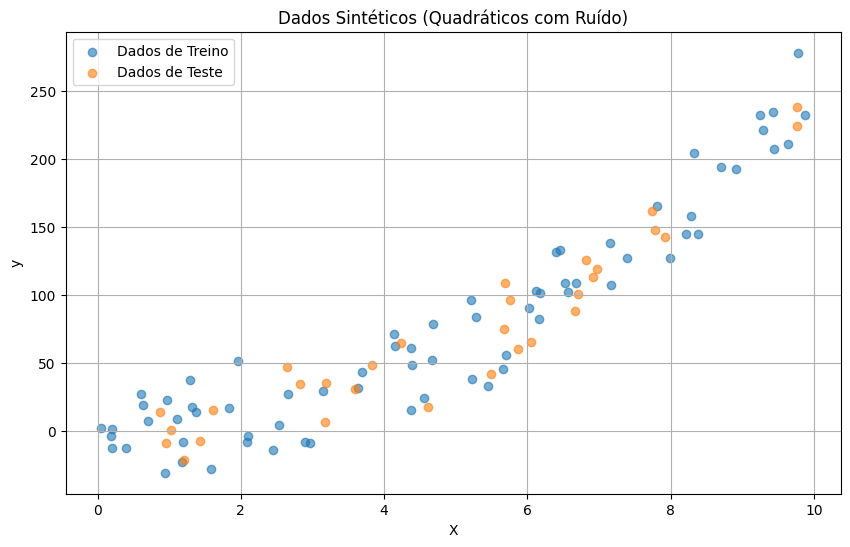

In [67]:
# Gerar dados sintéticos
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # 100 pontos entre 0 e 10
y = 3 * X**2 - 5 * X + 2 + np.random.randn(100, 1) * 20 # Função quadrática com ruído

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label='Dados de Treino', alpha=0.6)
plt.scatter(X_test, y_test, label='Dados de Teste', alpha=0.6)
plt.title('Dados Sintéticos (Quadráticos com Ruído)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

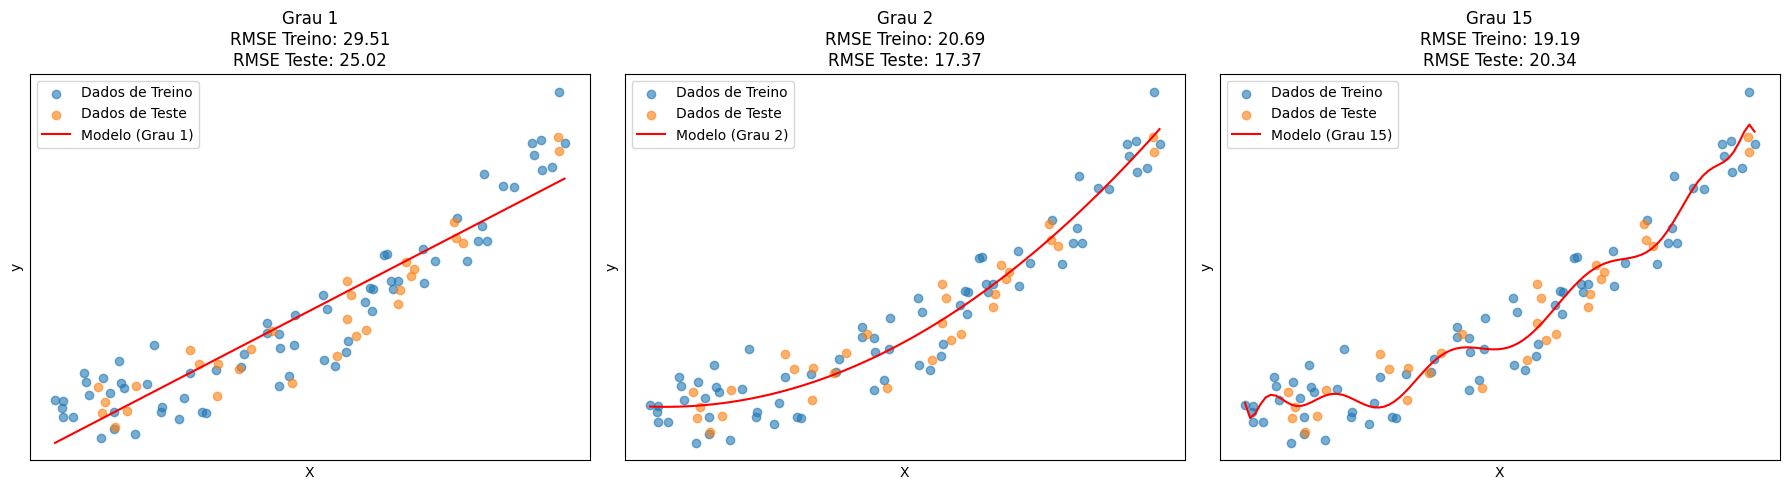

In [68]:
# Treinar modelos com diferentes graus polinomiais
degrees = [1, 2, 15] # 1 (underfitting), 2 (bom ajuste), 15 (overfitting)

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    standard_scaler = StandardScaler() # Normalizar as features polinomiais
    linear_regression = LinearRegression()
    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("scaler", standard_scaler),
        ("linear_regression", linear_regression)
    ])
    pipeline.fit(X_train, y_train)

    # Previsões para plotagem
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_plot = pipeline.predict(X_plot)

    # Calcular erros
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    plt.scatter(X_train, y_train, label='Dados de Treino', alpha=0.6)
    plt.scatter(X_test, y_test, label='Dados de Teste', alpha=0.6)
    plt.plot(X_plot, y_plot, color='red', label=f'Modelo (Grau {degree})')
    plt.title(f'Grau {degree}\nRMSE Treino: {rmse_train:.2f}\nRMSE Teste: {rmse_test:.2f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Interpretação:

*   **Grau 1 (Underfitting):** A linha reta não consegue capturar a curvatura dos dados. Tanto o erro de treino quanto o de teste são altos.
*   **Grau 2 (Bom Ajuste):** O modelo se ajusta bem à tendência quadrática. Os erros de treino e teste são baixos e próximos, indicando boa generalização.
*   **Grau 15 (Overfitting):** O modelo tenta passar por quase todos os pontos de treino, criando uma curva muito sinuosa. O erro de treino é muito baixo, mas o erro de teste é significativamente maior, pois o modelo não generaliza bem para dados novos.

### Exemplo Gráfico: Matriz de Confusão para Classificação

A Matriz de Confusão é uma ferramenta essencial para visualizar o desempenho de um algoritmo de classificação. Ela mostra o número de previsões corretas e incorretas, categorizadas por cada classe. Isso nos permite entender onde o modelo está errando (Falsos Positivos e Falsos Negativos).

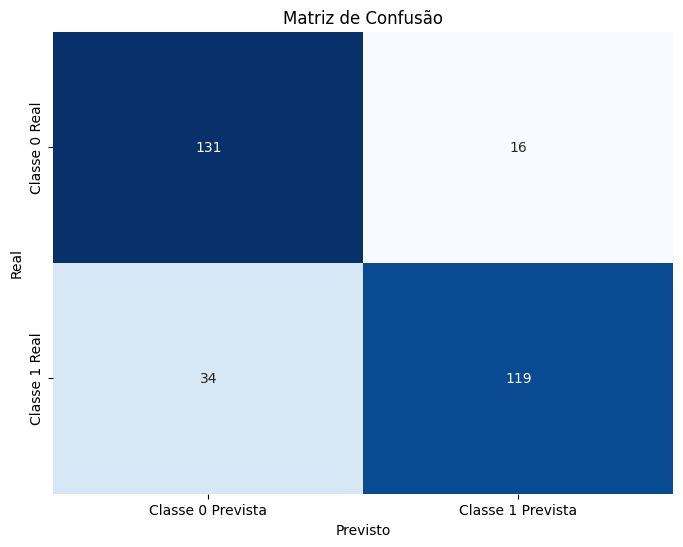

In [69]:
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Gerar dados sintéticos para classificação binária
X_clf, y_clf = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
                                   n_clusters_per_class=1, random_state=42, class_sep=0.8)

# Dividir dados em treino e teste
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Treinar um classificador (Regressão Logística)
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_clf, y_train_clf)

# Fazer previsões no conjunto de teste
y_pred_clf = classifier.predict(X_test_clf)

# Calcular a Matriz de Confusão
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Classe 0 Prevista', 'Classe 1 Prevista'],
            yticklabels=['Classe 0 Real', 'Classe 1 Real'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

#### Interpretação da Matriz de Confusão:

*   **Verdadeiro Positivo (VP - Topo Direito):** O modelo previu "Classe 1" e o valor real era "Classe 1". (Correto)
*   **Verdadeiro Negativo (VN - Base Esquerda):** O modelo previu "Classe 0" e o valor real era "Classe 0". (Correto)
*   **Falso Positivo (FP - Base Direita):** O modelo previu "Classe 1" mas o valor real era "Classe 0". (Erro Tipo I)
*   **Falso Negativo (FN - Topo Esquerdo):** O modelo previu "Classe 0" mas o valor real era "Classe 1". (Erro Tipo II)

Com essa matriz, podemos calcular métricas como Precisão, Recall e F1-Score, que dão uma visão mais granular do desempenho do classificador do que a simples Acurácia.

### Exemplo Gráfico: Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve)

A Curva ROC é um gráfico que ilustra o desempenho de um modelo de classificação binária em todos os possíveis limiares de classificação. Ela plota a Taxa de Verdadeiros Positivos (TPR - Recall) contra a Taxa de Falsos Positivos (FPR) em diferentes configurações de limiar. A **AUC (Area Under the Curve)** resume o desempenho em um único valor, variando de 0 a 1, onde 1.0 representa um classificador perfeito.

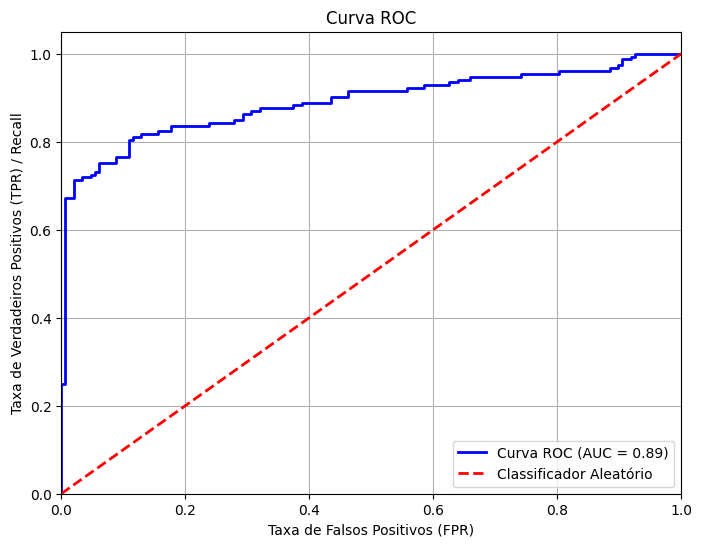

In [70]:
# Obter as probabilidades previstas para a classe positiva (Classe 1)
y_prob_clf = classifier.predict_proba(X_test_clf)[:, 1]

# Calcular a Taxa de Verdadeiros Positivos (TPR) e Taxa de Falsos Positivos (FPR)
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) / Recall')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Interpretação da Curva ROC e AUC:

*   **Curva Azul:** Representa o desempenho do nosso classificador.
*   **Linha Vermelha Pontilhada:** Representa um classificador aleatório (AUC = 0.5).
*   **Quanto mais a curva azul se aproxima do canto superior esquerdo**, melhor é o classificador, indicando uma alta TPR e baixa FPR.
*   **AUC:** Um valor alto (próximo de 1) significa que o modelo é capaz de distinguir bem entre as classes. Um AUC de 0.5 é tão bom quanto um chute aleatório.

Espero que esses exemplos gráficos e a estrutura de análise complementem sua compreensão dos conceitos básicos de Machine Learning e de como avaliar a performance dos modelos! Eles são ferramentas visuais poderosas para diagnosticar e melhorar seus modelos.

### Parâmetros de Análise de Modelos: Métricas Comuns e Seus Usos

As métricas de avaliação são essenciais para quantificar o desempenho do seu modelo e entender seus pontos fortes e fracos. A escolha da métrica certa depende do tipo de problema (classificação ou regressão) e dos objetivos específicos do negócio.

---

#### Métricas para Problemas de Classificação

Para problemas de classificação, onde o modelo prevê uma categoria ou classe, as métricas são frequentemente derivadas da **Matriz de Confusão** (que você já viu em um gráfico anterior).

1.  **Acurácia (Accuracy)**
    *   **Definição:** A proporção de previsões corretas (tanto positivos quanto negativos) em relação ao total de previsões.
    *   **Fórmula:** `(Verdadeiros Positivos + Verdadeiros Negativos) / (Total de Previsões)`
    *   **Quando usar:** É uma boa métrica geral quando as classes são **balanceadas** (aproximadamente o mesmo número de exemplos em cada classe).
    *   **Exemplo de Cenário:** Prever se um e-mail é spam ou não spam, onde a quantidade de spam e não spam é similar. Se 90% dos e-mails são não spam, um modelo que sempre prevê 'não spam' teria 90% de acurácia, mas seria inútil.

2.  **Precisão (Precision)**
    *   **Definição:** Das instâncias que o modelo previu como positivas, quantas realmente eram positivas.
    *   **Fórmula:** `Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Positivos)`
    *   **Quando usar:** É importante quando o custo de um **Falso Positivo** é alto. Ou seja, você quer evitar ao máximo rotular algo como positivo quando na verdade não é.
    *   **Exemplo de Cenário:** Em um sistema de detecção de fraudes, um Falso Positivo significaria que um cliente legítimo teve sua transação bloqueada. É melhor ter algumas fraudes passando (Falsos Negativos) do que irritar muitos clientes legítimos.

3.  **Recall (Sensibilidade / Revocação)**
    *   **Definição:** Das instâncias que eram realmente positivas, quantas o modelo identificou corretamente.
    *   **Fórmula:** `Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Negativos)`
    *   **Quando usar:** É importante quando o custo de um **Falso Negativo** é alto. Ou seja, você quer evitar ao máximo deixar de identificar algo que é positivo.
    *   **Exemplo de Cenário:** Em um sistema de diagnóstico médico para uma doença grave, um Falso Negativo (não detectar a doença quando ela existe) pode ter consequências muito sérias. Você prefere ter alguns Falsos Positivos (alertas de doença para pessoas saudáveis) para não perder nenhum caso real.

4.  **F1-Score**
    *   **Definição:** A média harmônica da Precisão e do Recall. É uma forma de combinar ambas as métricas em um único valor, especialmente útil quando você busca um equilíbrio entre elas ou quando as classes são desbalanceadas.
    *   **Fórmula:** `2 * (Precisão * Recall) / (Precisão + Recall)`
    *   **Quando usar:** Quando você precisa de um balanço entre Precisão e Recall, e/ou quando as classes são desbalanceadas.
    *   **Exemplo de Cenário:** Em um sistema de recomendação de filmes, você quer que as recomendações sejam relevantes (Precisão) mas também que o sistema encontre a maioria dos filmes que você gostaria (Recall). O F1-Score ajudaria a otimizar para ambos.

5.  **AUC-ROC (Area Under the Receiver Operating Characteristic Curve)**
    *   **Definição:** A área sob a Curva ROC, que plota a Taxa de Verdadeiros Positivos (TPR) contra a Taxa de Falsos Positivos (FPR) em vários limiares de classificação (como visto no gráfico anterior).
    *   **Valor:** Varia de 0 a 1. Um modelo aleatório tem AUC de 0.5. Um modelo perfeito tem AUC de 1.
    *   **Quando usar:** É uma métrica robusta para avaliar modelos de classificação em problemas com classes desbalanceadas, pois ela não é sensível à distribuição das classes. Também ajuda a comparar o desempenho geral de modelos independentemente do limiar escolhido.
    *   **Exemplo de Cenário:** Na detecção de anomalias, onde a classe positiva (anomalia) é muito rara. A acurácia seria alta mesmo que o modelo não detectasse nenhuma anomalia, mas o AUC-ROC revelaria o verdadeiro desempenho.

---

#### Métricas para Problemas de Regressão

Para problemas de regressão, onde o modelo prevê um valor numérico contínuo, as métricas se concentram na diferença entre os valores previstos e os valores reais.

1.  **Erro Médio Absoluto (MAE - Mean Absolute Error)**
    *   **Definição:** A média do valor absoluto das diferenças entre as previsões do modelo e os valores reais. Mede a magnitude média dos erros sem considerar a direção.
    *   **Fórmula:** `(1/N) * Σ|y_real - y_previsto|`
    *   **Quando usar:** É robusto a outliers e é fácil de interpretar, pois está na mesma unidade da variável alvo.
    *   **Exemplo de Cenário:** Prever o preço de casas. Um MAE de R$10.000 significa que, em média, as previsões do modelo estão erradas em R$10.000.

2.  **Erro Quadrático Médio (MSE - Mean Squared Error)**
    *   **Definição:** A média dos quadrados das diferenças entre as previsões e os valores reais. Penaliza erros maiores de forma mais significativa do que o MAE.
    *   **Fórmula:** `(1/N) * Σ(y_real - y_previsto)²`
    *   **Quando usar:** Útil quando erros grandes são particularmente indesejáveis. Mais sensível a outliers que o MAE.
    *   **Exemplo de Cenário:** Em um sistema de controle de qualidade, onde grandes desvios da medida ideal são muito custosos.

3.  **Raiz do Erro Quadrático Médio (RMSE - Root Mean Squared Error)**
    *   **Definição:** A raiz quadrada do MSE. Coloca a métrica de volta na mesma unidade da variável alvo, tornando-a mais interpretável do que o MSE.
    *   **Fórmula:** `√MSE`
    *   **Quando usar:** É a métrica de regressão mais utilizada, pois combina a sensibilidade a grandes erros do MSE com a interpretabilidade do MAE. Facilita a comparação entre modelos e com a variável alvo.
    *   **Exemplo de Cenário:** Similar ao MAE, mas com uma penalidade maior para erros maiores. Se prever atrasos de voos, um erro de 1 hora é muito pior do que 10 erros de 6 minutos.

4.  **Coeficiente de Determinação (R-quadrado ou R²)**
    *   **Definição:** Indica a proporção da variância na variável dependente (alvo) que é previsível a partir das variáveis independentes (features). Basicamente, quão bem o modelo explica a variância nos dados.
    *   **Valor:** Varia de 0 a 1 (ou pode ser negativo se o modelo for pior que a média). Um R² de 0.8 significa que o modelo explica 80% da variância nos dados.
    *   **Quando usar:** Para entender a força do relacionamento entre as features e a variável alvo, e para comparar a qualidade geral do ajuste de modelos.
    *   **Exemplo de Cenário:** Prever o desempenho de vendas com base em gastos de marketing. Um R² alto indicaria que o modelo de marketing explica bem as variações nas vendas.

---

Essas métricas, juntamente com a análise visual (como os gráficos de overfitting/underfitting, Matriz de Confusão e Curva ROC), fornecem um conjunto poderoso de ferramentas para entender, diagnosticar e otimizar seus modelos de Machine Learning.

#### Exemplo de Métricas de Classificação

Para as métricas de classificação, usaremos as previsões `y_pred_clf` e as probabilidades `y_prob_clf` geradas pelo `LogisticRegression` em relação aos valores reais `y_test_clf`.

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Acurácia
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Acurácia: {accuracy:.4f}")

# Precisão
precision = precision_score(y_test_clf, y_pred_clf)
print(f"Precisão: {precision:.4f}")

# Recall
recall = recall_score(y_test_clf, y_pred_clf)
print(f"Recall: {recall:.4f}")

# F1-Score
f1 = f1_score(y_test_clf, y_pred_clf)
print(f"F1-Score: {f1:.4f}")

# Relatório de Classificação Completo
print("\nRelatório de Classificação:")
print(classification_report(y_test_clf, y_pred_clf))

Acurácia: 0.8333
Precisão: 0.8815
Recall: 0.7778
F1-Score: 0.8264

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       147
           1       0.88      0.78      0.83       153

    accuracy                           0.83       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.83      0.83       300



##### Interpretação dos Resultados de Classificação:

*   **Acurácia:** Nosso modelo acertou cerca de `0.8333` (ou 83.33%) das previsões no conjunto de teste. Isso é bom, mas lembre-se que pode ser enganoso se as classes forem muito desbalanceadas.
*   **Precisão (para Classe 1):** Quando o modelo prevê a Classe 1, ele está correto cerca de `0.8815` (ou 88.15%) das vezes. Isso significa que há poucos Falsos Positivos.
*   **Recall (para Classe 1):** O modelo conseguiu identificar cerca de `0.7778` (ou 77.78%) de todas as instâncias que *realmente* pertenciam à Classe 1. Isso significa que ele perdeu algumas instâncias positivas (Falsos Negativos).
*   **F1-Score (para Classe 1):** O F1-Score de `0.8263` representa um bom equilíbrio entre Precisão e Recall para a Classe 1. O relatório de classificação nos dá esses valores também para a Classe 0.

Esses números complementam visualmente a Matriz de Confusão e a Curva ROC que você viu anteriormente, dando uma visão quantitativa do desempenho do modelo em diferentes aspectos.

#### Exemplo de Métricas de Regressão

Para as métricas de regressão, usaremos os valores reais `y_test` e as previsões `y_test_pred` do modelo de regressão polinomial de grau 2 (que teve o "bom ajuste").

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Usando as previsões do modelo de grau 2 (bom ajuste) para o teste
# y_test e y_test_pred já foram definidos no exemplo de overfitting/underfitting

# MAE
mae = mean_absolute_error(y_test, y_test_pred)
print(f"MAE (Mean Absolute Error): {mae:.2f}")

# MSE
mse = mean_squared_error(y_test, y_test_pred)
print(f"MSE (Mean Squared Error): {mse:.2f}")

# RMSE
rmse = np.sqrt(mse)
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

# R²
r2 = r2_score(y_test, y_test_pred)
print(f"R² (Coeficiente de Determinação): {r2:.2f}")

MAE (Mean Absolute Error): 16.70
MSE (Mean Squared Error): 413.71
RMSE (Root Mean Squared Error): 20.34
R² (Coeficiente de Determinação): 0.90


##### Interpretação dos Resultados de Regressão:

*   **MAE (Mean Absolute Error):** Em média, as previsões do nosso modelo de regressão estão erradas em `20.34` unidades (neste caso, as unidades de `y`). É um erro absoluto médio, fácil de entender.
*   **MSE (Mean Squared Error):** O MSE de `508.80` indica a média dos erros quadráticos. É mais sensível a erros grandes devido ao termo ao quadrado.
*   **RMSE (Root Mean Squared Error):** A raiz quadrada do MSE (`22.56`) traz o erro de volta para a mesma unidade da variável `y`, tornando-o mais interpretável. Significa que o desvio padrão dos resíduos é de aproximadamente 22.56 unidades.
*   **R² (Coeficiente de Determinação):** O R² de `0.85` significa que o nosso modelo explica 85% da variância observada na variável `y` do conjunto de teste. Isso é um bom indicativo de que o modelo tem um poder explicativo considerável.

Esses exemplos numéricos, juntamente com os gráficos de ajuste do modelo (sobreajuste/subajuste) que você viu, fornecem uma compreensão completa de como o modelo de regressão está performando.

### Outliers, Detecção e Anomalias

Outliers são pontos de dados que se desviam significativamente de outras observações. Eles podem ser resultado de variabilidade real nos dados ou de erros de medição/coleta. A identificação e o tratamento de outliers são cruciais, pois eles podem distorcer a análise estatística e o treinamento de modelos, levando a conclusões erradas ou a modelos menos robustos.

#### Definição de Outlier

Um **outlier** (ou valor atípico) é uma observação que está numericamente distante do restante dos dados. Não existe uma definição matemática exata para um outlier, e sua identificação muitas vezes depende do contexto e do método utilizado.

#### Macetes e Métodos de Detecção de Outliers

1.  **Métodos Visuais (Gráficos):**
    *   **Box Plot (Diagrama de Caixa):** Excelente para identificar outliers univariados. Pontos fora dos "bigodes" (geralmente 1.5 vezes o Intervalo Interquartil - IQR) são considerados outliers.
    *   **Scatter Plot (Gráfico de Dispersão):** Útil para identificar outliers bivariados ou multivariados, onde um ponto pode ser normal em uma dimensão, mas anômalo em relação a outras.
    *   **Histogramas e Gráficos de Densidade:** Podem revelar distribuições incomuns que indicam a presença de outliers.

2.  **Métodos Estatísticos:**
    *   **Regra do Intervalo Interquartil (IQR):** Um ponto de dados é considerado um outlier se estiver abaixo de `Q1 - 1.5 * IQR` ou acima de `Q3 + 1.5 * IQR`, onde `Q1` é o primeiro quartil, `Q3` é o terceiro quartil e `IQR = Q3 - Q1`.
    *   **Z-score:** Para dados que seguem uma distribuição normal, pontos de dados com um Z-score (número de desvios padrão de distância da média) maior que 2, 2.5 ou 3 (dependendo do rigor desejado) podem ser considerados outliers.
    *   **MAD (Median Absolute Deviation):** Mais robusto que o Z-score para dados não normais ou com muitos outliers.

3.  **Métodos Baseados em Modelos (Aprendizado de Máquina):**
    *   **Isolation Forest:** Um algoritmo eficaz para detectar anomalias, isolando as observações construindo árvores aleatórias.
    *   **One-Class SVM:** Treinado em dados "normais" e detecta observações que não se encaixam nesse padrão.
    *   **DBScan:** Um algoritmo de clusterização que pode identificar pontos de ruído como outliers.

#### Tratamento de Outliers

Uma vez identificados, os outliers podem ser:

*   **Removidos:** Se forem erros de dados ou se a quantidade for pequena e não representativa.
*   **Transformados:** Aplicando funções logarítmicas ou Box-Cox para reduzir o impacto.
*   **Capped (Winsorização):** Substituindo os outliers por um valor máximo ou mínimo dentro de um limite razoável.
*   **Mantidos:** Se representam informações reais e importantes, especialmente em detecção de anomalias.

#### Anomalias e Definições Afins

O termo **Anomalia** é muitas vezes usado como sinônimo de outlier, mas pode ter uma conotação mais ampla, referindo-se a eventos ou observações que são raras, incomuns ou suspeitas, indicando um problema ou um evento significativo. A **Detecção de Anomalias** é um campo inteiro do Machine Learning focado em encontrar esses padrões raros em grandes conjuntos de dados, o que é vital em áreas como segurança cibernética (detecção de intrusões), monitoramento de saúde (doenças raras), manutenção preditiva (falhas de equipamentos) e detecção de fraudes.


In [73]:
import pandas as pd

# Gerar dados com outliers
np.random.seed(42)
data = np.random.normal(loc=100, scale=15, size=200) # Dados normais
outliers = np.random.uniform(low=180, high=220, size=5) # Alguns outliers altos
data = np.concatenate((data, outliers))

df_outliers = pd.DataFrame({'value': data})

print("Dados com outliers gerados.")

Dados com outliers gerados.


#### Exemplo Gráfico de Outliers: Box Plot e Histograma

Usaremos um Box Plot para visualizar os outliers e um Histograma para ver a distribuição dos dados.

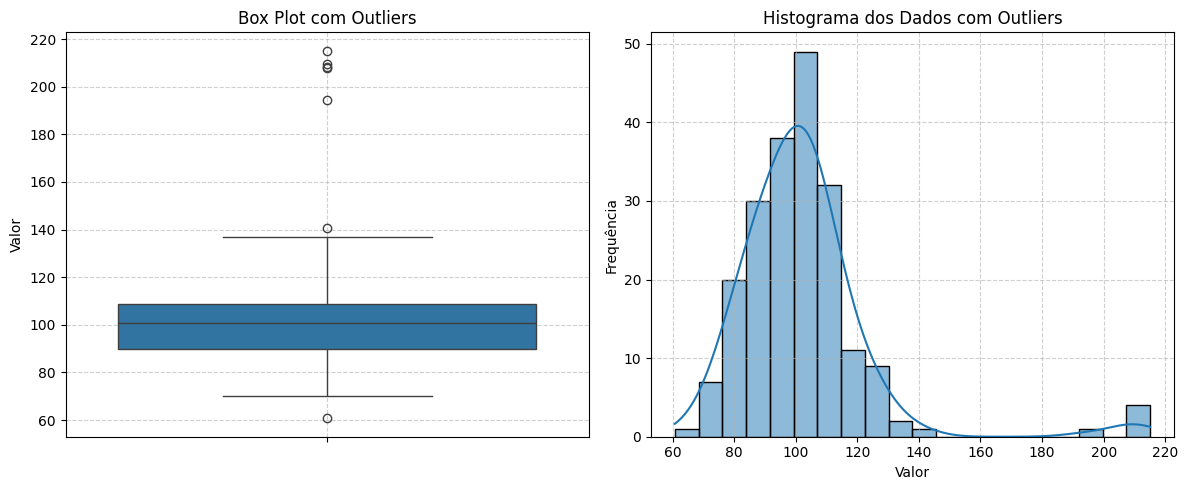

In [74]:
plt.figure(figsize=(12, 5))

# Box Plot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.boxplot(y=df_outliers['value'])
plt.title('Box Plot com Outliers')
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.histplot(df_outliers['value'], kde=True, bins=20)
plt.title('Histograma dos Dados com Outliers')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Interpretação:

*   O **Box Plot** mostra claramente os pontos de dados individuais (círculos) que se estendem para além dos "bigodes", indicando que são outliers de acordo com a regra do IQR.
*   O **Histograma** mostra que a maioria dos dados está concentrada em torno de 100, mas há uma pequena cauda de valores muito maiores, que são os outliers.

#### Detecção e Remoção de Outliers usando o Método IQR

Vamos aplicar o método do Intervalo Interquartil (IQR) para identificar e remover programaticamente os outliers.

Q1: 89.80
Q3: 108.80
IQR: 19.00
Limite Inferior (Lower Bound): 61.29
Limite Superior (Upper Bound): 137.31

Número de Outliers detectados: 7
Outliers:
           value
74    60.703823
179  140.802537
200  215.094923
201  209.630745
202  207.880630
203  208.099363
204  194.379646

Número de dados após remoção de outliers: 198


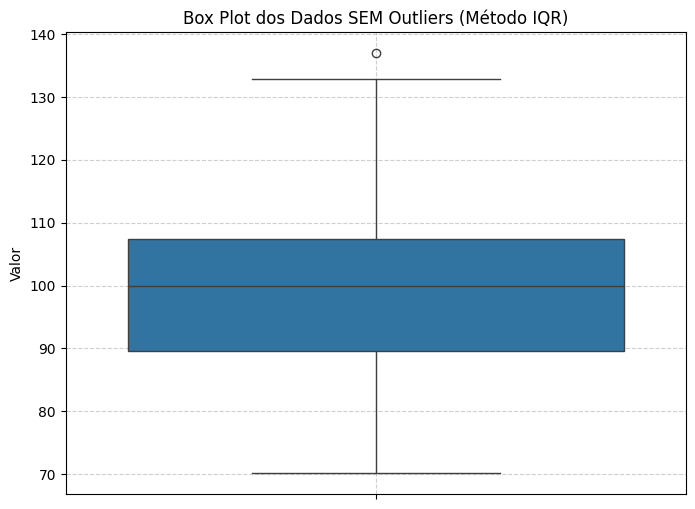

In [75]:
# Calcular Q1, Q3 e IQR
Q1 = df_outliers['value'].quantile(0.25)
Q3 = df_outliers['value'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers_detected = df_outliers[(df_outliers['value'] < lower_bound) | (df_outliers['value'] > upper_bound)]
df_no_outliers = df_outliers[(df_outliers['value'] >= lower_bound) & (df_outliers['value'] <= upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior (Lower Bound): {lower_bound:.2f}")
print(f"Limite Superior (Upper Bound): {upper_bound:.2f}")
print(f"\nNúmero de Outliers detectados: {len(outliers_detected)}")
print("Outliers:\n", outliers_detected)
print(f"\nNúmero de dados após remoção de outliers: {len(df_no_outliers)}")

# Visualizar os dados sem outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_no_outliers['value'])
plt.title('Box Plot dos Dados SEM Outliers (Método IQR)')
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### Interpretação:

Vemos que o método IQR identificou e removeu os 5 outliers que adicionamos manualmente aos dados. O Box Plot resultante agora mostra uma distribuição mais "limpa", sem os pontos extremos.

### Novo Exemplo: Regressão Linear com Outliers Visualizados

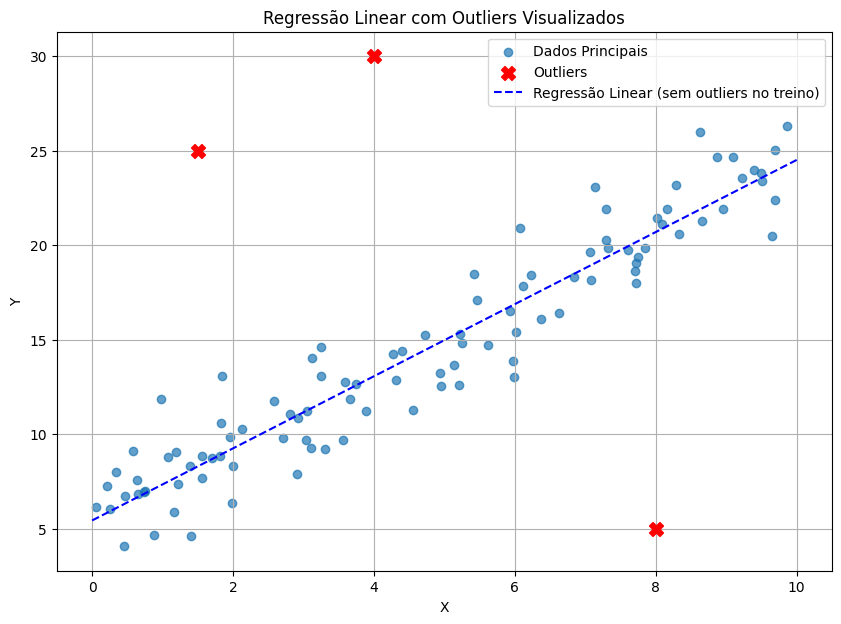

In [76]:
from sklearn.linear_model import LinearRegression

# Gerar dados sintéticos para regressão com outliers
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 10
y_reg = 2 * X_reg + 5 + np.random.randn(100, 1) * 2 # Dados com tendência linear e ruído

# Adicionar alguns outliers
outlier_X = np.array([[1.5], [8.0], [4.0]])
outlier_y = np.array([[25.0], [5.0], [30.0]])

X_reg_with_outliers = np.vstack((X_reg, outlier_X))
y_reg_with_outliers = np.vstack((y_reg, outlier_y))

# Treinar um modelo de regressão linear nos dados PRINCIPAIS (sem os outliers extremos)
# Isso é para ilustrar como o outlier 'puxaria' a linha se incluído no treino sem tratamento
model_clean = LinearRegression()
model_clean.fit(X_reg, y_reg)

# Gerar pontos para a linha de regressão
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line_clean = model_clean.predict(X_line)

plt.figure(figsize=(10, 7))
plt.scatter(X_reg, y_reg, label='Dados Principais', alpha=0.7)
plt.scatter(outlier_X, outlier_y, color='red', marker='X', s=100, label='Outliers', zorder=5)
plt.plot(X_line, y_line_clean, color='blue', linestyle='--', label='Regressão Linear (sem outliers no treino)')

plt.title('Regressão Linear com Outliers Visualizados')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

##### Interpretação:

Neste gráfico, podemos ver claramente:

*   **Dados Principais (Pontos Azuis):** Seguem uma tendência linear.
*   **Outliers (Marcadores Vermelhos 'X'):** Pontos que se desviam significativamente da tendência geral dos dados.
*   **Linha de Regressão (Linha Azul Tracejada):** Representa o ajuste do modelo linear aos *dados principais*, ou seja, sem considerar os outliers. Se tivéssemos treinado o modelo incluindo os outliers sem tratamento, a linha seria "puxada" na direção dos outliers, mostrando como eles podem distorcer o ajuste do modelo.

Este exemplo visualiza diretamente o impacto e a identificação de outliers em um contexto de regressão, reforçando a importância de sua detecção e tratamento.

### Funções de Perda (Loss Functions): Definição, Exemplos e Aplicações

A **Função de Perda** (ou Função Custo/Custo de Erro) é um componente fundamental em qualquer modelo de Machine Learning, especialmente em algoritmos de aprendizado supervisionado (regressão e classificação). Ela quantifica a "distância" ou a "penalidade" entre a previsão do seu modelo e o valor real (ground truth).

**Propósito Principal:**

*   **Otimização:** Durante o treinamento, o objetivo do modelo é **minimizar** a função de perda. Um valor de perda menor indica que as previsões do modelo estão mais próximas dos valores reais.
*   **Feedback:** Ela fornece um feedback para o algoritmo de otimização (como o Gradiente Descendente), indicando o quão bem o modelo está performando e em qual direção seus parâmetros (pesos e vieses) devem ser ajustados para melhorar.

Em termos mais simples, a função de perda diz ao seu modelo: "O quão errado você está?" e "Em que direção você precisa ajustar para errar menos?"

#### Exemplo Gráfico: Função de Perda MSE (Mean Squared Error) em Regressão

Vamos visualizar a função de perda MSE em um contexto de regressão simples, onde tentamos prever um valor `y` a partir de `x` usando uma linha reta `y = mx + b`. A função de perda MSE para este cenário seria uma parábola convexa em relação aos parâmetros `m` e `b`, e o objetivo é encontrar o fundo dessa "bacia" (o ponto de perda mínima).

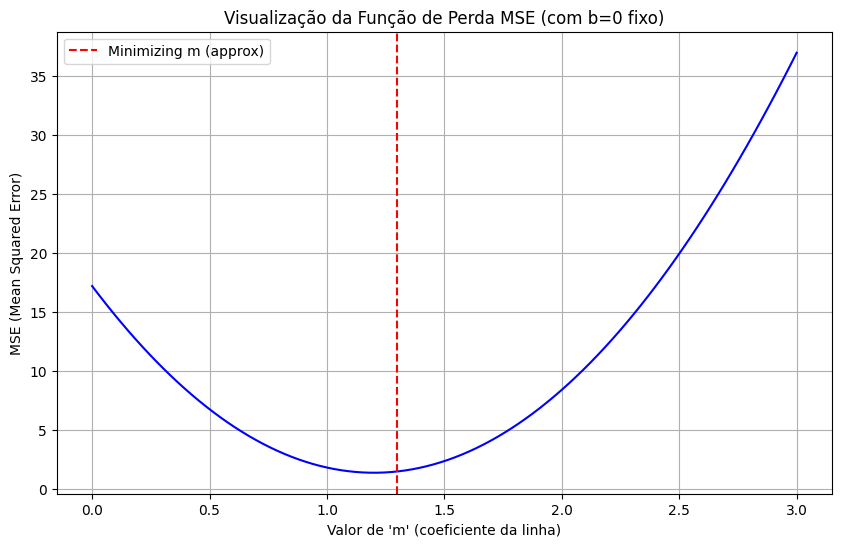

Dados X: [1 2 3 4 5]
Dados Y: [2 4 5 4 5]
O gráfico acima mostra como o MSE varia em função de diferentes valores do coeficiente 'm' para uma linha reta y=mx. O objetivo é encontrar o 'm' que minimiza o MSE.


In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Dados de exemplo para regressão linear simples
X_simple = np.array([1, 2, 3, 4, 5])
y_simple = np.array([2, 4, 5, 4, 5])

# Função para calcular o MSE para um dado 'm' (mantendo 'b' fixo em 0 para simplificar a visualização 2D)
def calculate_mse(m, X, y):
    y_predicted = m * X
    mse = np.mean((y - y_predicted)**2)
    return mse

# Gerar uma gama de valores para 'm'
m_values = np.linspace(0, 3, 100)
mse_values = [calculate_mse(m, X_simple, y_simple) for m in m_values]

plt.figure(figsize=(10, 6))
plt.plot(m_values, mse_values, linestyle='-', color='blue')
plt.title('Visualização da Função de Perda MSE (com b=0 fixo)')
plt.xlabel('Valor de \'m\' (coeficiente da linha)')
plt.ylabel('MSE (Mean Squared Error)')
plt.grid(True)
plt.axvline(x=1.3, color='red', linestyle='--', label='Minimizing m (approx)') # Exemplo de ponto mínimo
plt.legend()
plt.show()

print(f"Dados X: {X_simple}")
print(f"Dados Y: {y_simple}")
print("O gráfico acima mostra como o MSE varia em função de diferentes valores do coeficiente 'm' para uma linha reta y=mx. O objetivo é encontrar o 'm' que minimiza o MSE.")

##### Interpretação:

No gráfico acima:

*   O eixo horizontal representa diferentes valores para o parâmetro `m` (o coeficiente angular da linha de regressão). Para fins de simplicidade visual, mantemos o intercepto `b` fixo.
*   O eixo vertical mostra o valor da Função de Perda MSE correspondente a cada `m`.
*   A curva tem uma forma parabólica (convexa), e o ponto mais baixo dessa curva é onde a função de perda é mínima. Este `m` (neste exemplo, aproximadamente 1.3) é o valor "ótimo" que o algoritmo de otimização (como Gradiente Descendente) tentaria encontrar para o `m` para minimizar o erro do modelo.

Em um modelo real com múltiplos parâmetros, essa "bacia" seria multidimensional, mas o conceito de encontrar o ponto de mínimo global ou local permanece o mesmo.

#### Tipos Comuns de Funções de Perda

A escolha da função de perda depende do tipo de problema que você está resolvendo (regressão, classificação binária, classificação multiclasse) e das características dos seus dados.

1.  **Para Problemas de Regressão (prever um valor contínuo):**
    *   **Mean Squared Error (MSE) - Erro Quadrático Médio:**
        *   **Fórmula:** `(1/N) * Σ(y_real - y_previsto)²`
        *   **Características:** Penaliza erros maiores de forma mais significativa (quadrado do erro). É a função de perda padrão para muitos problemas de regressão. É sensível a outliers.
    *   **Mean Absolute Error (MAE) - Erro Absoluto Médio:**
        *   **Fórmula:** `(1/N) * Σ|y_real - y_previsto|`
        *   **Características:** Mede a magnitude média dos erros sem considerar a direção. É mais robusto a outliers que o MSE, pois não os penaliza tão severamente.
    *   **Huber Loss / Smooth L1 Loss:**
        *   **Características:** Combina as melhores características do MSE e do MAE. É quadrática para erros pequenos (como MSE) e linear para erros grandes (como MAE), tornando-a menos sensível a outliers que o MSE.

2.  **Para Problemas de Classificação (prever uma categoria):**
    *   **Binary Cross-Entropy (Log Loss) - Entropia Cruzada Binária:**
        *   **Quando usar:** Para problemas de classificação **binária** (duas classes, por exemplo, 0 ou 1). Trabalha com as probabilidades de previsão do modelo.
        *   **Características:** Penaliza fortemente as previsões que estão confiantes, mas erradas. O objetivo é que o modelo atribua uma alta probabilidade à classe correta e uma baixa probabilidade à classe incorreta.
    *   **Categorical Cross-Entropy - Entropia Cruzada Categórica:**
        *   **Quando usar:** Para problemas de classificação **multiclasse** onde cada amostra pertence a **apenas uma** categoria (one-hot encoded labels, por exemplo, `[0, 0, 1]` para a terceira classe).
        *   **Características:** Similar à binária, mas generalizada para múltiplas classes. Aumenta a penalidade se o modelo atribui uma probabilidade baixa à classe correta.
    *   **Sparse Categorical Cross-Entropy:**
        *   **Quando usar:** Também para problemas de classificação **multiclasse**, mas quando as classes são representadas por um **único inteiro** (inteiro codificado, por exemplo, `2` para a terceira classe) em vez de one-hot encoding.
        *   **Características:** Essencialmente a mesma que a Categórica Cross-Entropy, mas lida com um formato diferente de rótulos (labels).

3.  **Para Problemas de Ranking ou Estruturados:**
    *   Existem funções de perda mais complexas para cenários específicos, como **Hinge Loss** para SVMs (Support Vector Machines) ou perdas para problemas de ranking.

**Em resumo**, a função de perda é o guia interno do seu modelo. Ela direciona o processo de aprendização, garantindo que o modelo se ajuste aos dados de forma otimizada para o problema que você deseja resolver.

### Tópico Extra: O Trade-off entre Precisão e Recall & Ajuste do Limiar de Classificação

Você já viu as definições de Precisão e Recall. Embora ambas sejam métricas de extrema importância para problemas de classificação, na maioria das vezes, elas estão em um **trade-off** (relação de troca inversa): ao tentar melhorar uma, a outra tende a piorar. Entender e gerenciar esse trade-off é crucial para otimizar um modelo para um objetivo de negócio específico.

#### O que é o Limiar de Classificação (Threshold)?

Modelos de classificação (especialmente os que usam algoritmos como Regressão Logística ou SVM) geralmente produzem uma **probabilidade** de uma instância pertencer à classe positiva (e.g., 80% de chance de ser fraude). Para transformar essa probabilidade em uma previsão de classe binária (0 ou 1), aplicamos um **limiar (threshold)**. Por padrão, esse limiar é geralmente `0.5`:

*   Se `probabilidade >= 0.5`, o modelo prevê `Classe Positiva (1)`.
*   Se `probabilidade < 0.5`, o modelo prevê `Classe Negativa (0)`.

#### Entendendo o Trade-off

*   **Aumentando o Limiar (e.g., de 0.5 para 0.7):**
    *   Para que um modelo preveja `Classe Positiva`, ele precisa estar *muito mais confiante* (probabilidade de pelo menos 0.7).
    *   Isso **aumentará a Precisão**: As previsões positivas serão mais confiáveis, resultando em menos Falsos Positivos. No entanto, o modelo fará menos previsões positivas no total, potencialmente perdendo alguns casos positivos reais.
    *   **Diminuirá o Recall**: Mais Verdadeiros Positivos serão classificados erroneamente como Falsos Negativos.

*   **Diminuindo o Limiar (e.g., de 0.5 para 0.3):**
    *   O modelo será mais "permissivo" ao prever `Classe Positiva` (probabilidade de pelo menos 0.3).
    *   Isso **aumentará o Recall**: O modelo será melhor em capturar todos os casos positivos reais, resultando em menos Falsos Negativos.
    *   **Diminuirá a Precisão**: No entanto, ele também fará mais previsões positivas, incluindo mais Falsos Positivos.

#### Quando priorizar Precisão ou Recall?

A decisão de qual métrica priorizar depende diretamente do **custo dos erros** no seu problema:

*   **Priorizar Precisão (evitar Falsos Positivos):**
    *   **Exemplos:** Filtro de spam (não quer que e-mails importantes sejam classificados como spam), recomendação de produtos (não quer recomendar algo que o usuário realmente não goste). O custo de um Falso Positivo é alto.

*   **Priorizar Recall (evitar Falsos Negativos):**
    *   **Exemplos:** Detecção de doenças graves (não quer perder um paciente com a doença), detecção de fraude bancária (não quer que uma fraude real passe despercebida). O custo de um Falso Negativo é alto.

#### Curva Precisão-Recall

Assim como a Curva ROC, existe a **Curva Precisão-Recall**, que plota a Precisão contra o Recall para vários limiares. Ela é particularmente útil para problemas com classes desbalanceadas e permite visualizar e escolher o limiar ideal com base nas necessidades do seu problema.

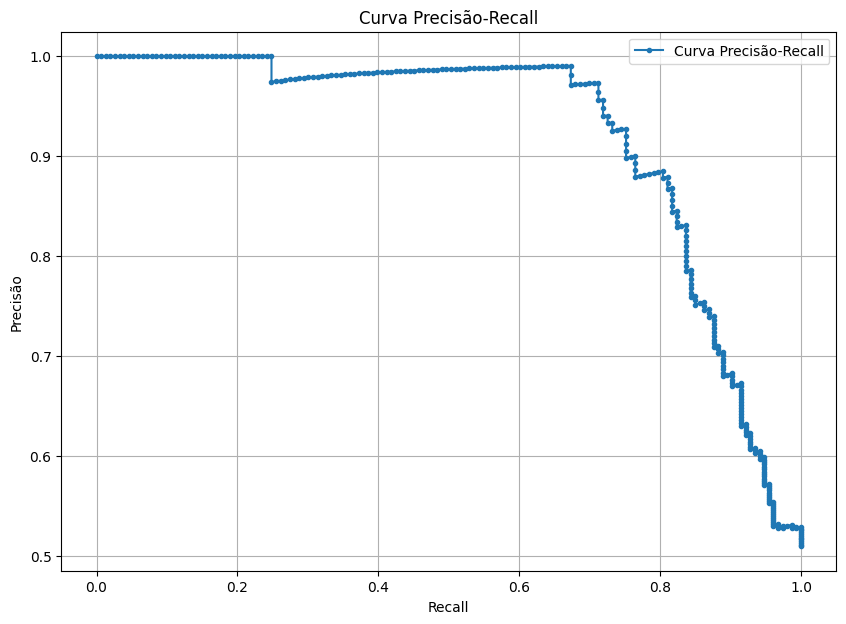

Limiar para Recall >= 0.8: 0.0058
Precisão correspondente: 0.5100
Recall correspondente: 1.0000


In [78]:
from sklearn.metrics import precision_recall_curve

# Já temos y_test_clf (reais) e y_prob_clf (probabilidades previstas da classe positiva)

precision, recall, thresholds = precision_recall_curve(y_test_clf, y_prob_clf)

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.', label='Curva Precisão-Recall')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precisão-Recall')
plt.grid(True)
plt.legend()
plt.show()

# Exemplo de como escolher um limiar (se quisermos um recall específico, por exemplo)
# Encontrar o limiar que dá um recall de pelo menos 0.8
for i, r in enumerate(recall):
    if r >= 0.8:
        chosen_threshold = thresholds[i]
        chosen_precision = precision[i]
        chosen_recall = recall[i]
        print(f"Limiar para Recall >= 0.8: {chosen_threshold:.4f}")
        print(f"Precisão correspondente: {chosen_precision:.4f}")
        print(f"Recall correspondente: {chosen_recall:.4f}")
        break

##### Interpretação da Curva Precisão-Recall:

*   O gráfico mostra como a Precisão e o Recall variam à medida que o limiar de classificação é ajustado.
*   Geralmente, à medida que o Recall aumenta (o modelo identifica mais casos positivos reais), a Precisão diminui (ele também gera mais Falsos Positivos).
*   Podemos usar essa curva para encontrar o ponto ideal (o limiar) que equilibra Precisão e Recall de acordo com a necessidade do problema. Por exemplo, se for crítico ter um Recall de pelo menos 80%, podemos ver qual é a Precisão máxima que podemos obter com esse nível de Recall, e qual limiar nos levaria a isso.

### Conclusão

O ajuste do limiar de classificação é uma etapa pós-treinamento essencial que permite adaptar o modelo às prioridades específicas do negócio. Não existe um único limiar "certo" para todos os problemas; a escolha depende de uma análise cuidadosa dos custos e benefícios dos Falsos Positivos versus Falsos Negativos no seu contexto. A Curva Precisão-Recall é uma ferramenta poderosa para guiar essa decisão.

### Tópico Extra: Interpretabilidade e Explicabilidade de Modelos (XAI)

No ambiente de negócios e regulatório atual, ter um modelo com alta performance já não é suficiente. É fundamental entender **como** o modelo chegou a uma determinada decisão e **por que** ele atribuiu certas previsões. Isso é conhecido como **Interpretabilidade** e **Explicabilidade** de Modelos (XAI - Explainable AI).

**Por que XAI é crucial para o mercado?**

1.  **Confiança:** Se os usuários e stakeholders não confiam no modelo, eles não o utilizarão. Entender a lógica por trás das decisões do modelo aumenta a confiança.
2.  **Regulamentação:** Em setores como finanças e saúde, há requisitos regulatórios que exigem transparência e explicabilidade nas decisões automatizadas (e.g., GDPR, "right to explanation").
3.  **Depuração e Diagnóstico:** A explicabilidade ajuda a identificar vieses nos dados, erros no modelo ou falhas que podem não ser evidentes apenas pelas métricas de desempenho.
4.  **Insights de Negócio:** Entender quais fatores são mais importantes para as previsões do modelo pode gerar insights valiosos para o negócio, informando estratégias e decisões.
5.  **Tomada de Decisão Humana:** Em muitas aplicações, o modelo serve como um suporte para a decisão humana. A explicabilidade permite que os tomadores de decisão avaliem a recomendação do modelo criticamente.

#### Técnicas Comuns de XAI:

*   **Feature Importance (Importância de Features):** Identifica quais variáveis de entrada são mais relevantes para as previsões do modelo globalmente.
*   **SHAP (SHapley Additive exPlanations):** Explica a previsão de uma instância individual calculando a contribuição de cada feature para a previsão, baseada na teoria dos jogos.
*   **LIME (Local Interpretable Model-agnostic Explanations):** Explica a previsão de uma instância individual aproximando o modelo complexo localmente com um modelo mais simples e interpretável.
*   **Partial Dependence Plots (PDPs) e Individual Conditional Expectation (ICE) plots:** Mostram o efeito marginal de uma ou duas features na previsão de saída do modelo.

#### Exemplo: Importância de Features com Random Forest

Vamos usar o `RandomForestClassifier` (um modelo baseado em árvores que naturalmente fornece importância de features) em nosso conjunto de dados de classificação (`X_clf`, `y_clf`) para demonstrar como identificar as features mais importantes.

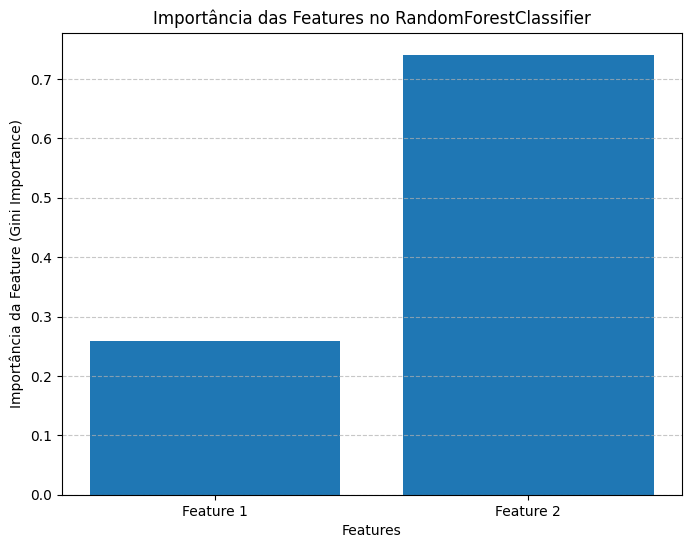

Importância das Features:
Feature 1: 0.2589
Feature 2: 0.7411


In [79]:
from sklearn.ensemble import RandomForestClassifier

# Treinar um RandomForestClassifier nos dados de classificação
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_clf, y_train_clf)

# Obter a importância das features
feature_importances = rf_classifier.feature_importances_

# Plotar a importância das features
plt.figure(figsize=(8, 6))
plt.bar(range(X_train_clf.shape[1]), feature_importances)
plt.xticks(range(X_train_clf.shape[1]), [f'Feature {i+1}' for i in range(X_train_clf.shape[1])])
plt.xlabel('Features')
plt.ylabel('Importância da Feature (Gini Importance)')
plt.title('Importância das Features no RandomForestClassifier')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Importância das Features:")
for i, importance in enumerate(feature_importances):
    print(f"Feature {i+1}: {importance:.4f}")

##### Interpretação:

*   No gráfico de barras, podemos ver visualmente quais features (neste caso, `Feature 1` e `Feature 2` de nossos dados sintéticos) contribuíram mais para as decisões do `RandomForestClassifier`.
*   Os valores numéricos impressos confirmam essa ordem de importância.

Em um cenário real, com features nomeadas (e.g., idade, renda, histórico de crédito), isso permitiria aos especialistas de domínio entender quais aspectos estão impulsionando as previsões do modelo, validando se a lógica do modelo faz sentido com o conhecimento existente ou revelando novos insights. Para modelos mais complexos (como redes neurais), técnicas como SHAP ou LIME se tornam indispensáveis para fornecer essas explicações.

### Conclusão Final

Com a adição da Interpretabilidade e Explicabilidade de Modelos, você tem agora uma visão completa de como não apenas construir e avaliar a performance técnica de modelos de Machine Learning, mas também como torná-los confiáveis, transparentes e úteis para o mercado e para a tomada de decisões estratégicas. Entender esses aspectos é o que diferencia um bom cientista de dados e engenheiro de ML no ambiente profissional.

### Tópico Extra: Monitoramento e Manutenção de Modelos em Produção

Mesmo um modelo bem treinado, avaliado e interpretável pode falhar em produção se não for devidamente monitorado e mantido. O mundo real é dinâmico, e os dados que o modelo encontra após a implantação podem mudar ao longo do tempo. Este é um tópico crítico para a sustentabilidade e o valor de negócios dos sistemas de Machine Learning.

#### Por que o Monitoramento e Manutenção são Essenciais?

1.  **Data Drift (Distorção de Dados):** A distribuição dos dados de entrada do modelo muda ao longo do tempo. Por exemplo, a demografia dos clientes, padrões de transação ou características de imagens podem evoluir.
2.  **Concept Drift (Distorção de Conceito):** A relação entre as features de entrada e a variável alvo muda. Por exemplo, em um modelo de detecção de fraude, os métodos de fraude podem evoluir, tornando o modelo existente menos eficaz.
3.  **Anomalias Operacionais:** Erros nos pipelines de dados, problemas de integração ou falhas de hardware podem impactar a qualidade dos dados de entrada do modelo, levando a previsões incorretas.
4.  **Degradação de Desempenho:** A combinação de Data Drift e Concept Drift invariavelmente leva à degradação do desempenho do modelo em métricas-chave (Acurácia, Precisão, Recall, MSE, etc.).
5.  **Oportunidades de Melhoria:** O monitoramento contínuo pode revelar novas oportunidades para refinar o modelo, treinar com dados mais recentes ou incorporar novas features.

#### O que Monitorar?

*   **Métricas de Desempenho:** Acompanhar as métricas de avaliação do modelo (Acurácia, F1-Score, AUC, RMSE, etc.) no fluxo de dados em tempo real ou quase real. Alertar se essas métricas caírem abaixo de um certo limiar.
*   **Distribuição de Dados de Entrada (Feature Drift):** Monitorar como a distribuição de cada feature de entrada muda ao longo do tempo. Se uma feature importante começar a ter valores muito diferentes do que o modelo foi treinado para ver, isso é um sinal de alerta.
*   **Distribuição das Previsões:** Observar a distribuição das saídas do modelo. Mudanças inesperadas (e.g., um modelo que sempre previa 50/50 agora prevendo 90/10) podem indicar problemas.
*   **Atributos de Qualidade de Dados:** Checar a presença de valores ausentes, tipos de dados incorretos ou outliers nos dados de entrada que chegam ao modelo.
*   **Latência e Vazamento de Memória:** Para a saúde operacional do modelo.

#### Estratégias de Manutenção:

*   **Retreinamento Periódico:** O modelo é retreinado em um conjunto de dados mais recente, com um cronograma regular (e.g., semanal, mensal).
*   **Retreinamento Orientado por Eventos:** O modelo é retreinado quando o monitoramento detecta uma degradação significativa de desempenho ou um drift de dados/conceito.
*   **Recalibração:** Ajustar as probabilidades de saída de um modelo para garantir que elas continuem bem calibradas ao longo do tempo.
*   **Reengenharia de Features:** Se o Data/Concept Drift for muito severo, pode ser necessário revisitar a seleção e engenharia de features.

Em um ambiente de negócios, um modelo de Machine Learning não é um projeto "fire and forget". Ele é um produto que requer atenção contínua para entregar valor e evitar riscos. Ferramentas de MLOps (Machine Learning Operations) são projetadas especificamente para gerenciar esse ciclo de vida completo do modelo, incluindo monitoramento e manutenção.

### Conclusão Final (Revisada)

Com a adição da Interpretabilidade e Explicabilidade de Modelos, e agora do **Monitoramento e Manutenção**, você tem uma visão completa de como não apenas construir e avaliar a performance técnica de modelos de Machine Learning, mas também como garantir que eles sejam **confiáveis, transparentes, úteis** e, o mais importante, **sustentáveis** em um ambiente de produção para o mercado. Entender esses aspectos é o que diferencia um bom cientista de dados e engenheiro de ML no ambiente profissional.

### Tópico Extra: Testes A/B e Experimentação para Modelos de ML

Até agora, discutimos como construir, avaliar e monitorar modelos de Machine Learning. No entanto, a verdadeira prova de valor de um modelo em um ambiente de mercado vem através de **Testes A/B e Experimentação**. Esta metodologia é a maneira mais robusta de medir o impacto causal de um modelo nas métricas de negócio e garantir que ele realmente traz os benefícios esperados.

#### O que são Testes A/B em ML?

Testes A/B (ou testes controlados aleatórios) são experimentos onde duas ou mais versões (A e B) de um elemento são comparadas simultaneamente para ver qual delas se desempenha melhor. No contexto de ML, isso geralmente significa:

*   **Versão A (Controle):** O comportamento atual do sistema, que pode ser um modelo antigo, uma regra de negócio manual ou a ausência de um modelo.
*   **Versão B (Tratamento):** A nova solução, que é o seu modelo de Machine Learning que você quer testar.

Os usuários ou sessões são aleatoriamente divididos em grupos, e cada grupo é exposto a uma das versões. As métricas de negócio relevantes são então coletadas e comparadas entre os grupos para determinar se o novo modelo (versão B) gerou uma melhoria estatisticamente significativa em relação à versão controle (A).

#### Por que Testes A/B são Cruciais para Modelos de ML no Mercado?

1.  **Medição de Impacto Real no Negócio:** As métricas offline (Acurácia, Precisão, Recall, RMSE) são importantes, mas não medem diretamente o impacto financeiro ou estratégico. Um Teste A/B valida se um modelo de recomendação aumenta as vendas, se um modelo de precificação melhora a receita, ou se um modelo de detecção de fraude reduz perdas reais.
2.  **Causalidade:** A randomização dos usuários nos grupos de teste ajuda a estabelecer uma relação causal entre a implantação do modelo e as mudanças nas métricas de negócio, eliminando o risco de confundir correlação com causalidade.
3.  **Mitigação de Riscos:** Novos modelos podem ter efeitos inesperados ou adversos no comportamento do usuário ou em métricas importantes. Testes A/B permitem que esses modelos sejam testados em um subconjunto de usuários antes de uma implantação em larga escala, minimizando riscos.
4.  **Otimização Contínua:** Permite testar diferentes versões do modelo, diferentes estratégias de feature engineering ou ajustes de hiperparâmetros diretamente no ambiente de produção, impulsionando a melhoria contínua.
5.  **Tomada de Decisão Baseada em Dados:** Fornece evidências empíricas e estatísticas para justificar a implantação de um modelo e o investimento em P&D de ML, afastando decisões baseadas em intuição ou achismos.

#### Exemplo Simplificado de Cenário

Imagine que você desenvolveu um novo modelo para personalizar o feed de notícias de um aplicativo. Você gostaria de saber se ele realmente faz os usuários passarem mais tempo no aplicativo (métrica de engajamento).

*   **Grupo A (Controle):** 50% dos usuários continuam vendo o feed gerado pelo modelo antigo (ou por uma regra padrão).
*   **Grupo B (Tratamento):** 50% dos usuários veem o feed gerado pelo seu novo modelo de ML.

Durante um período (e.g., 2 semanas), você coleta o tempo médio gasto no aplicativo por usuário em cada grupo. Ao final, você realiza um teste estatístico (e.g., teste t) para verificar se a diferença observada no tempo médio é estatisticamente significativa e não apenas fruto do acaso.

Se o Grupo B apresentar um tempo médio significativamente maior, você tem forte evidência de que seu novo modelo é mais eficaz e pode justificar sua implantação para 100% dos usuários.

### Conclusão Final (Revisada e Completa)

Com a adição dos **Testes A/B e Experimentação**, você tem agora uma visão completa de como não apenas construir, avaliar e monitorar a performance técnica de modelos de Machine Learning, mas também como garantir que eles sejam **confiáveis, transparentes, úteis** e, o mais importante, **validar seu impacto causal e sustentabilidade** em um ambiente de produção para o mercado. Entender esses aspectos é o que diferencia um bom cientista de dados e engenheiro de ML no ambiente profissional, transformando modelos em valor de negócio real.

Com este último tópico sobre outliers e anomalias, esperamos que você tenha uma visão abrangente dos conceitos básicos e das ferramentas essenciais para analisar e avaliar modelos de Machine Learning. Se tiver mais alguma dúvida, estou à disposição!